In [1]:
import pandas as pd

# Load the CSV file into a DataFrame with error handling
try:
    df_train = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
    print("File loaded successfully.")
except FileNotFoundError:
    print("The file was not found. Please check the file path.")

# Display the last few rows of the DataFrame before deleting the columns
print("DataFrame before deleting 'education' and 'output' columns:")
print(df_train.tail())

# Delete the 'education' column
if 'education' in df_train.columns:
    df_train.drop(columns=['education'], inplace=True)
    print("'education' column deleted successfully.")


# Delete the 'output' column
if 'output' in df_train.columns:
    df_train.drop(columns=['output'], inplace=True)
    print("'output' column deleted successfully.")


# Display the last few rows of the DataFrame after deleting the columns
print("\nDataFrame after deleting 'education' and 'output' columns:")
print(df_train.tail())




File loaded successfully.
DataFrame before deleting 'education' and 'output' columns:
         Loan_ID Gender Married Dependents Self_Employed  ApplicantIncome  \
LP002978  Female     No       0         No          2900                0   
LP002979    Male    Yes      3+         No          4106                0   
LP002983    Male    Yes       1        NaN            No             8072   
LP002984    Male    Yes       2         No          7583                0   
LP002990  Female     No       0        Yes           453                0   

          CoapplicantIncome  LoanAmount  Loan_Amount_Term Credit_History  \
LP002978               71.0       360.0               1.0          Rural   
LP002979               40.0       180.0               1.0          Rural   
LP002983              240.0       253.0             360.0              1   
LP002984              187.0       360.0               1.0          Urban   
LP002990              133.0       360.0               0.0      Semiurba

In [2]:
import pandas as pd

# Checking for missing data 
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

# Creating a DataFrame to hold the total and percentage of missing data
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Change percentage values to whole numbers
missing_data['Percent'] = missing_data['Percent'].astype(int)

# Display the top 20 columns with missing data
missing_data.head(20)




,Total,Percent
Credit_History,50,8
Self_Employed,32,5
LoanAmount,22,3
Married,15,2
Loan_Amount_Term,14,2
Loan_ID,13,2
Loan_Status,5,0
Gender,3,0
Dependents,1,0
ApplicantIncome,0,0


In [3]:
# Filling missing categorical columns with the mode
for column in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']:
    df_train[column] = df_train[column].fillna(df_train[column].dropna().mode()[0])

# Filling the 'LoanAmount' column with the mean
df_train['LoanAmount'] = df_train['LoanAmount'].fillna(df_train['LoanAmount'].mean())
df_train['Credit_History'].value_counts()

Credit_History
1            521
0             88
Rural          3
Urban          1
Semiurban      1
Name: count, dtype: int64

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean column names
df_train.columns = df_train.columns.str.title()

# Verify columns
print(df_train.columns)
# Create a FacetGrid with seaborn, using 'Gender' as rows and 'Education' as columns
grid = sns.FacetGrid(df_train, row='Gender', col='Education', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)
# Add a legend
grid.add_legend()


Index(['Loan_Id', 'Gender', 'Married', 'Dependents', 'Self_Employed',
       'Applicantincome', 'Coapplicantincome', 'Loanamount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


KeyError: 'Education'

In [ ]:
# Create a FacetGrid with seaborn, using 'Gender' as rows and 'Education' as columns
grid = sns.FacetGrid(df_train, row='Gender', col='Education', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()

KeyError: 'Education'

In [ ]:
# Create a FacetGrid with seaborn, using 'Married' as rows and 'Education' as columns
grid = sns.FacetGrid(df_train, row='Married', col='Education', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()

KeyError: 'Education'

In [ ]:
# Create a FacetGrid with seaborn, using 'Self_Employed' as rows and 'Education' as columns
grid = sns.FacetGrid(df_train, row='Self_Employed', col='Education', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()


KeyError: 'Education'

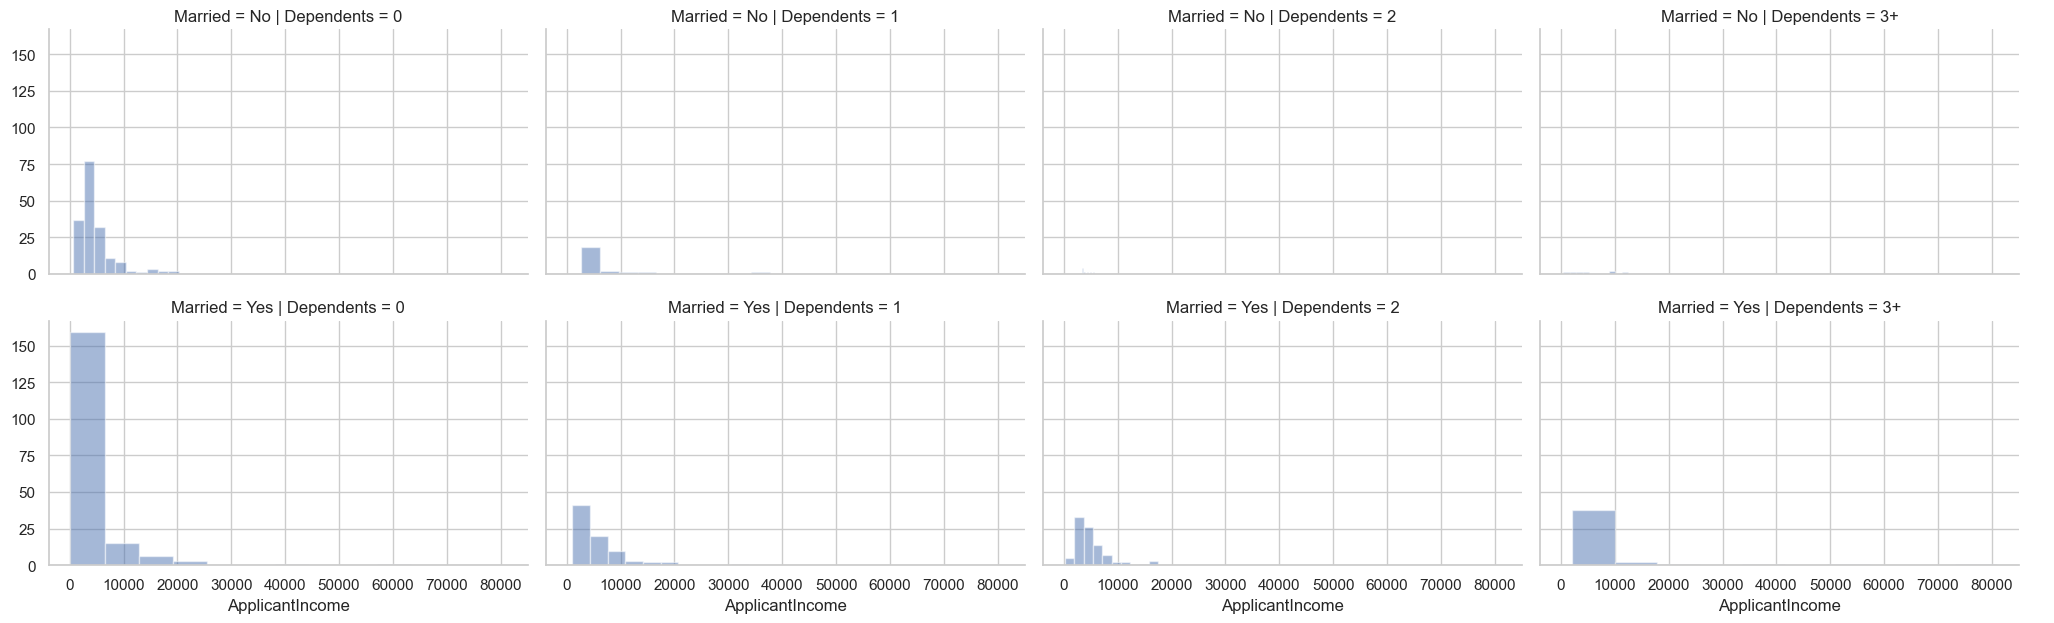

In [ ]:
# Create a FacetGrid with seaborn, using 'Married' as rows and 'Dependents' as columns
grid = sns.FacetGrid(df_train, row='Married', col='Dependents', height=3.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()


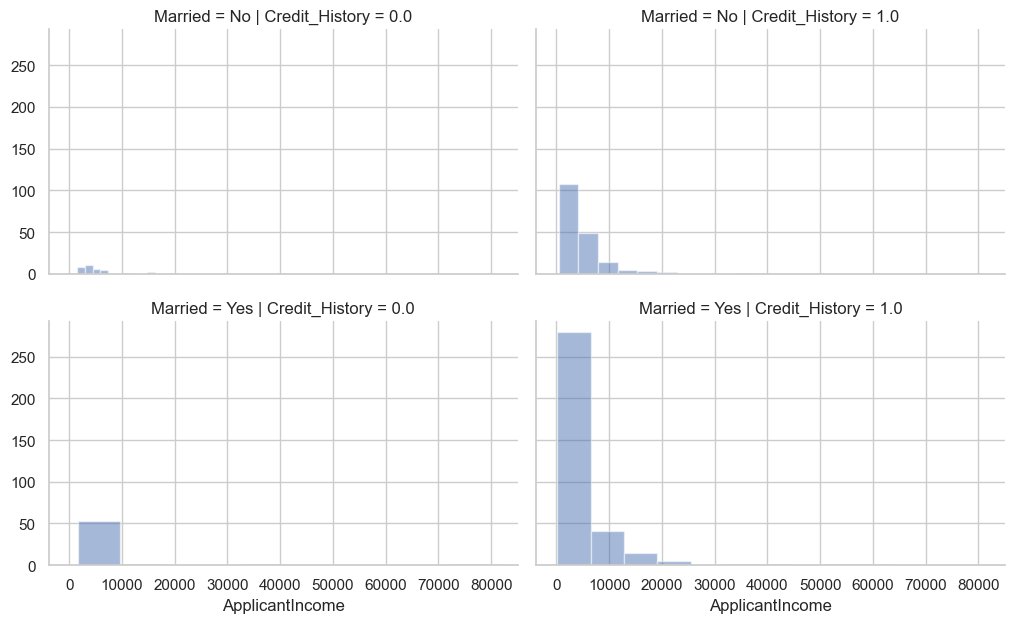

In [ ]:
# Create a FacetGrid with seaborn, using 'Married' as rows and 'Credit_History' as columns
grid = sns.FacetGrid(df_train, row='Married', col='Credit_History', height=3.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()


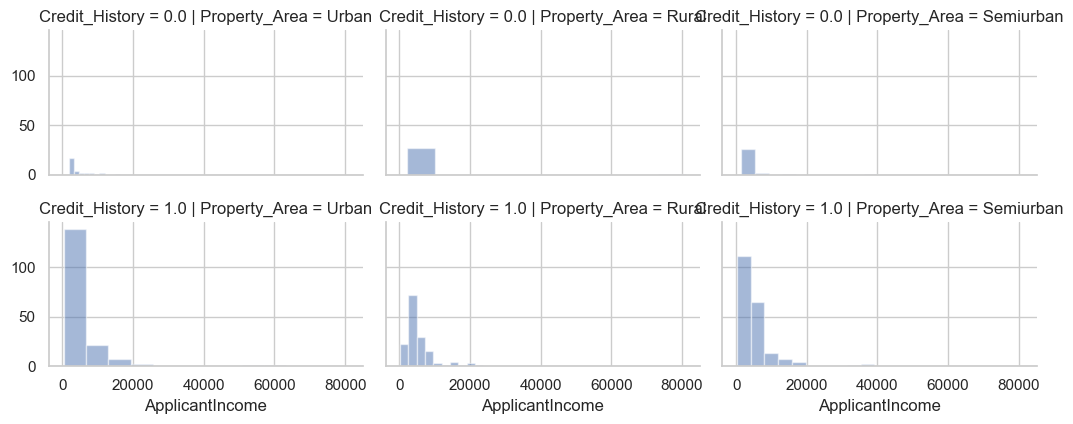

In [ ]:
# Create a FacetGrid with seaborn, using 'Credit_History' as rows and 'Property_Area' as columns
grid = sns.FacetGrid(df_train, row='Credit_History', col='Property_Area', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()


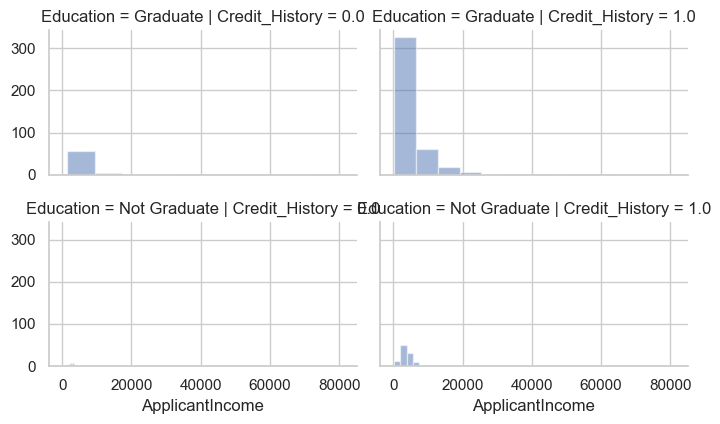

In [ ]:
# Create a FacetGrid with seaborn, using 'Education' as rows and 'Credit_History' as columns
grid = sns.FacetGrid(df_train, row='Education', col='Credit_History', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'ApplicantIncome'
grid.map(plt.hist, 'ApplicantIncome', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()


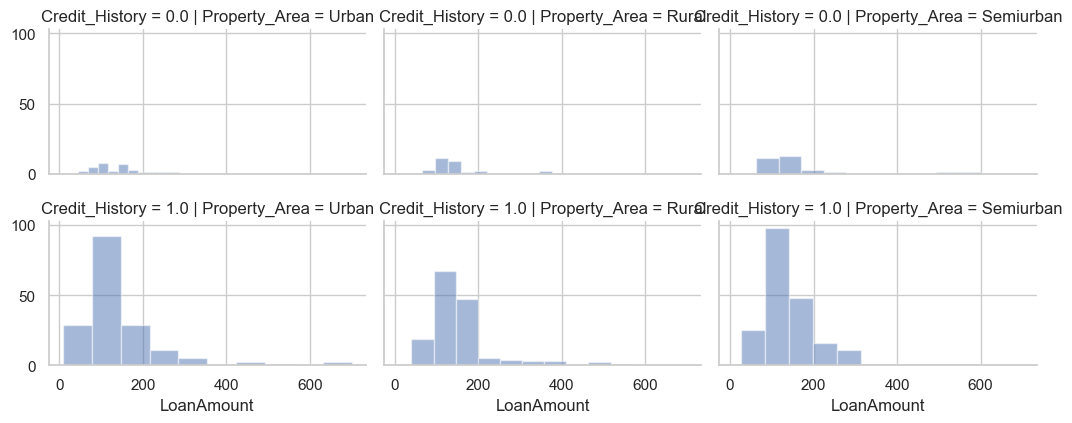

In [ ]:
# Create a FacetGrid with seaborn, using 'Credit_History' as rows and 'Property_Area' as columns
grid = sns.FacetGrid(df_train, row='Credit_History', col='Property_Area', height=2.2, aspect=1.6)

# Plot histograms on the grid for 'LoanAmount'
grid.map(plt.hist, 'LoanAmount', alpha=0.5, bins=10)

# Add a legend
grid.add_legend()  # Add parentheses to call the method


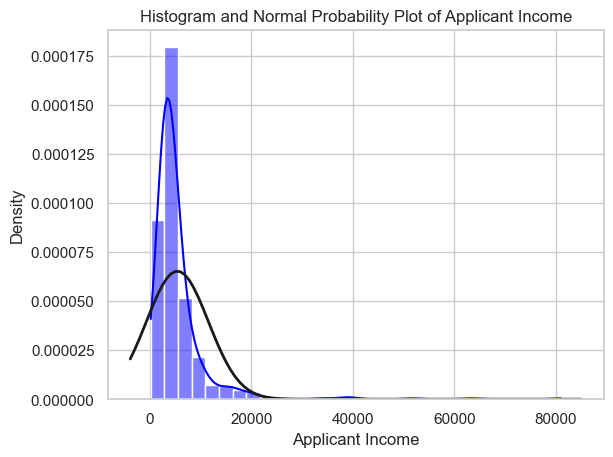

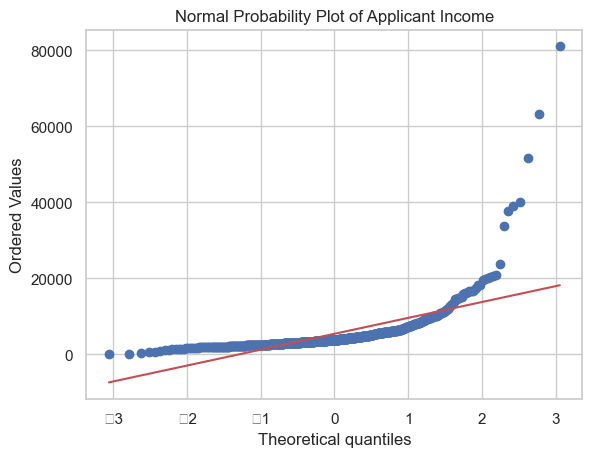

In [ ]:
# Create a histogram with a kernel density estimate
sns.histplot(df_train['ApplicantIncome'], kde=True, stat="density", bins=30, color='blue', alpha=0.5)

# Overlay a normal distribution curve
xmin, xmax = plt.xlim()  # Get the current x limits
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, df_train['ApplicantIncome'].mean(), df_train['ApplicantIncome'].std())  # Calculate normal distribution
plt.plot(x, p, 'k', linewidth=2)  # Plot the normal distribution

# Show the plot
plt.title('Histogram and Normal Probability Plot of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Density')
plt.show()

# Create a normal probability plot
fig = plt.figure()
res = stats.probplot(df_train['ApplicantIncome'], plot=plt)
plt.title('Normal Probability Plot of Applicant Income')
plt.show()


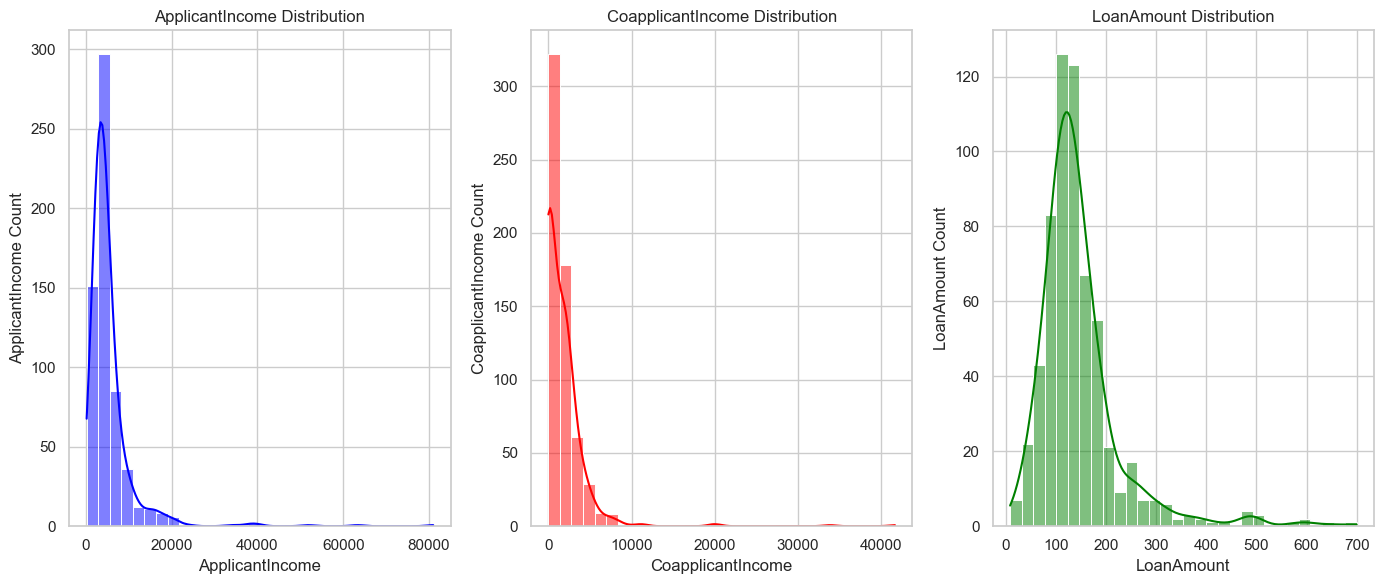

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create subplots for the distributions
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

# Plot ApplicantIncome distribution
sns.histplot(df_train['ApplicantIncome'], ax=axes[0], kde=True, color='blue', bins=30)
axes[0].set_title('ApplicantIncome Distribution')
axes[0].set_ylabel('ApplicantIncome Count')

# Plot CoapplicantIncome distribution
sns.histplot(df_train['CoapplicantIncome'], ax=axes[1], kde=True, color='red', bins=30)
axes[1].set_title('CoapplicantIncome Distribution')
axes[1].set_ylabel('CoapplicantIncome Count')

# Plot LoanAmount distribution
sns.histplot(df_train['LoanAmount'], ax=axes[2], kde=True, color='green', bins=30)
axes[2].set_title('LoanAmount Distribution')
axes[2].set_ylabel('LoanAmount Count')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Clear the current figure
plt.gcf().clear()


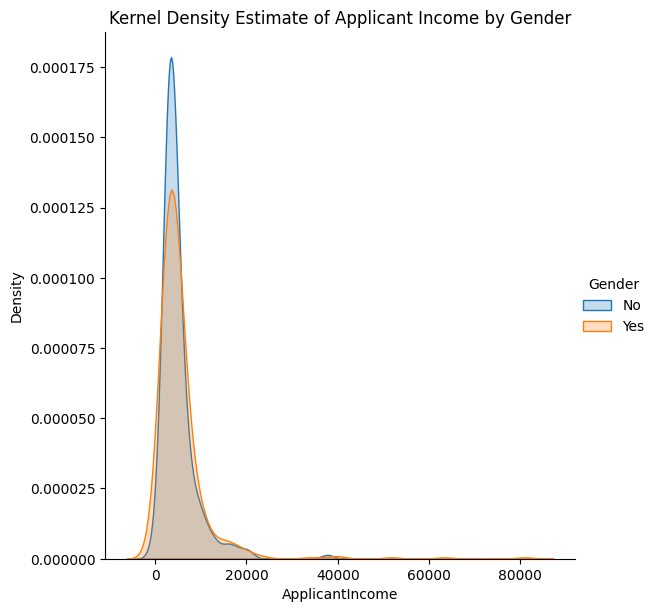

In [ ]:
# Create a FacetGrid with seaborn, using 'Gender' as the hue
g = sns.FacetGrid(df_train, hue="Gender", height=6)

# Map the kernel density estimate plot for 'ApplicantIncome'
g.map(sns.kdeplot, "ApplicantIncome", fill=True)  # 'fill=True' will fill the area under the curve

# Add a legend
g.add_legend()

# Show the plot
plt.title('Kernel Density Estimate of Applicant Income by Gender')
plt.show()


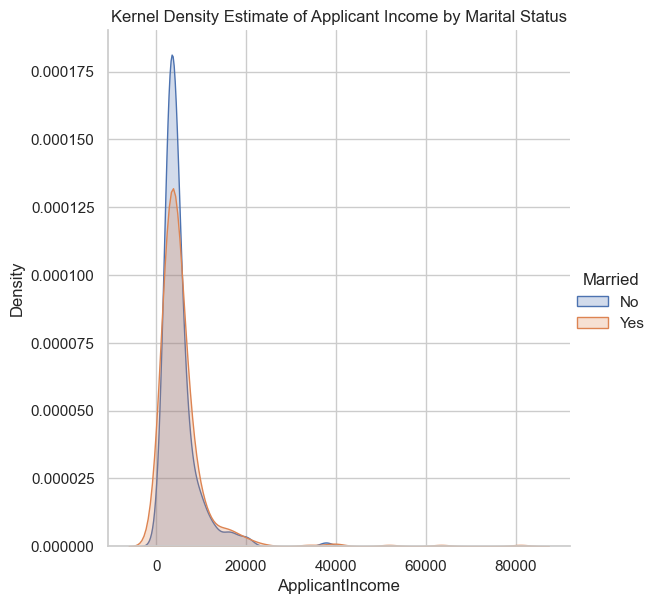

In [ ]:
# Create a FacetGrid with seaborn, using 'Married' as the hue
g = sns.FacetGrid(df_train, hue="Married", height=6)

# Map the kernel density estimate plot for 'ApplicantIncome'
g.map(sns.kdeplot, "ApplicantIncome", fill=True)  # Optional: fill the area under the curve

# Add a legend
g.add_legend()

# Show the plot
plt.title('Kernel Density Estimate of Applicant Income by Marital Status')
plt.show()


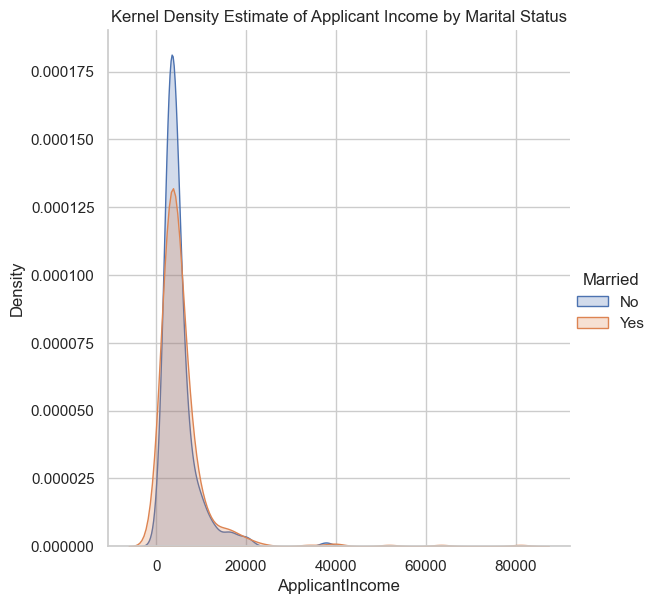

In [ ]:
# Create a FacetGrid with seaborn, using 'Married' as the hue
g = sns.FacetGrid(df_train, hue="Married", height=6)

# Map the kernel density estimate plot for 'ApplicantIncome'
g.map(sns.kdeplot, "ApplicantIncome", fill=True)  # Optional: fill the area under the curve

# Add a legend
g.add_legend()

# Show the plot
plt.title('Kernel Density Estimate of Applicant Income by Marital Status')
plt.show()


In [ ]:
df_train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

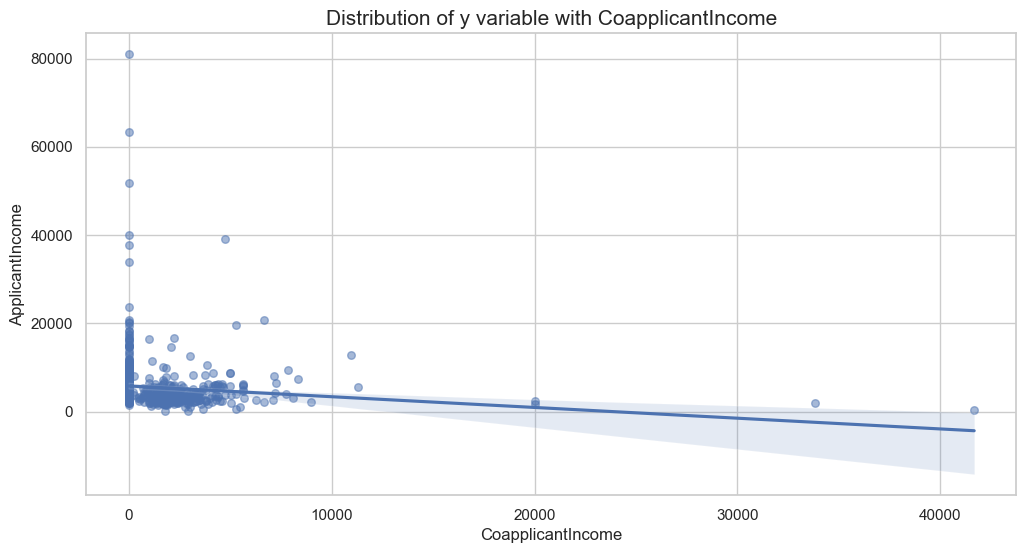

In [ ]:
var_name = "CoapplicantIncome"
plt.figure(figsize=(12,6))
sns.regplot(x=var_name, y='ApplicantIncome', data=df_train, scatter_kws={'alpha':0.5, 's':30})
plt.xlabel(var_name, fontsize=12)
plt.ylabel('ApplicantIncome', fontsize=12)
plt.title("Distribution of y variable with "+var_name, fontsize=15)
plt.show()

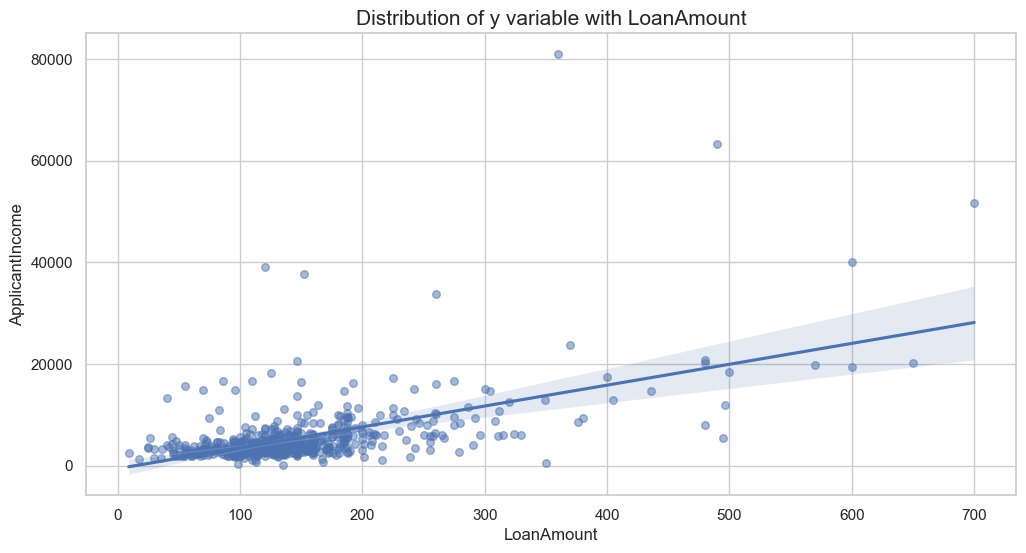

In [ ]:
var_name = "LoanAmount"
plt.figure(figsize=(12,6))
sns.regplot(x=var_name, y='ApplicantIncome', data=df_train, scatter_kws={'alpha':0.5, 's':30})
plt.xlabel(var_name, fontsize=12)
plt.ylabel('ApplicantIncome', fontsize=12)
plt.title("Distribution of y variable with "+var_name, fontsize=15)
plt.show()

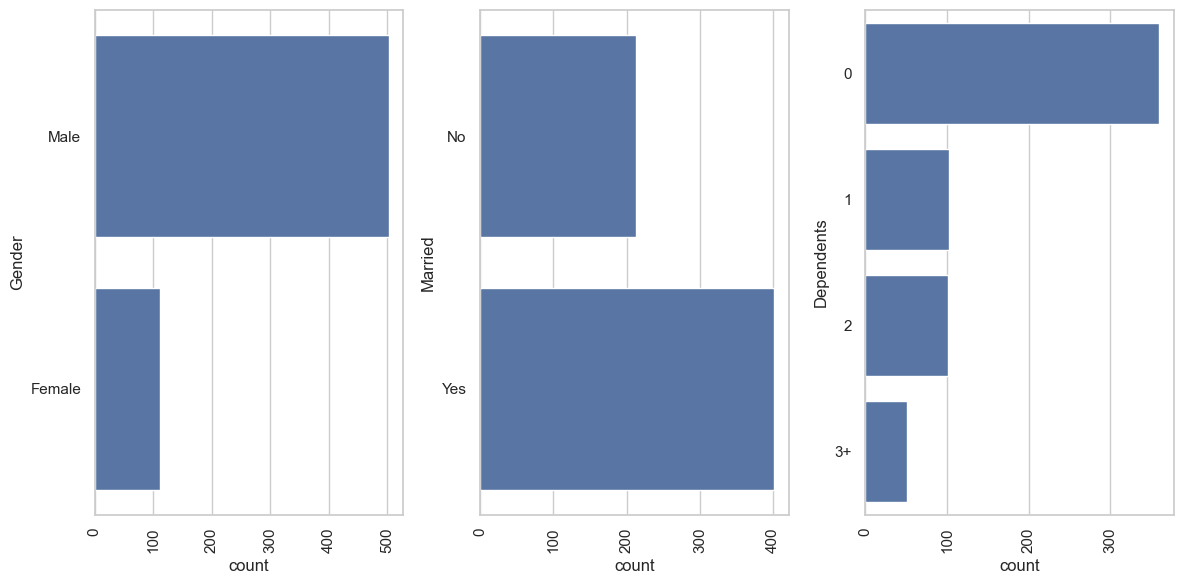

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(ncols=3,figsize=(12,6))

g = sns.countplot(df_train["Gender"], ax=axes[0])
plt.setp(g.get_xticklabels(), rotation=90)
g = sns.countplot(df_train["Married"], ax=axes[1])
plt.setp(g.get_xticklabels(), rotation=90)
g = sns.countplot(df_train["Dependents"], ax=axes[2])
plt.setp(g.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()
plt.gcf().clear()

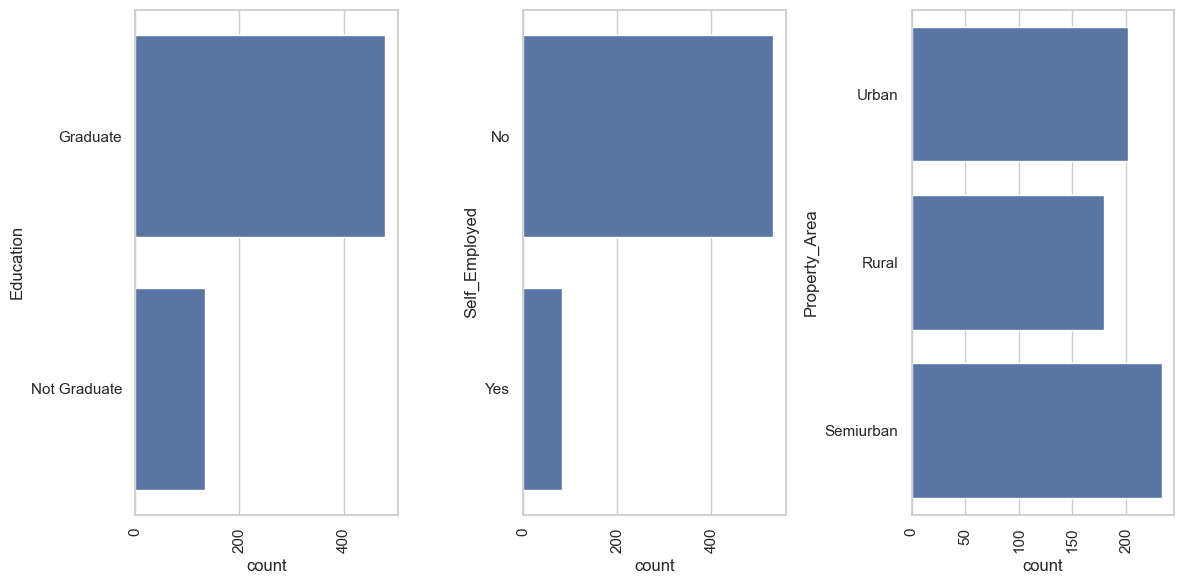

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(ncols=3,figsize=(12,6))

g = sns.countplot(df_train["Education"], ax=axes[0])
plt.setp(g.get_xticklabels(), rotation=90)
g = sns.countplot(df_train["Self_Employed"], ax=axes[1])
plt.setp(g.get_xticklabels(), rotation=90)
g = sns.countplot(df_train["Property_Area"], ax=axes[2])
plt.setp(g.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()
plt.gcf().clear()

In [ ]:
print(df_train.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  614.000000        614.000000   
mean       5403.459283        1621.245798  146.412162        342.410423   
std        6109.041673        2926.248369   84.037468         64.428629   
min         150.000000           0.000000    9.000000         12.000000   
25%        2877.500000           0.000000  100.250000        360.000000   
50%        3812.500000        1188.500000  129.000000        360.000000   
75%        5795.000000        2297.250000  164.750000        360.000000   
max       81000.000000       41667.000000  700.000000        480.000000   

       Credit_History  
count      614.000000  
mean         0.855049  
std          0.352339  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [ ]:
df_train.shape

(614, 13)

In [ ]:
df_train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df_train[['Gender', 'ApplicantIncome']].groupby(['Gender'],
                                               as_index = False).mean().sort_values(by = 'Gender', ascending = False)

,Gender,ApplicantIncome
1,Male,5573.017928
0,Female,4643.473214


In [ ]:
df_train[['Married', 'ApplicantIncome']].groupby(['Married'],
                                               as_index = False).mean().sort_values(by = 'Married', ascending = False)

,Married,ApplicantIncome
1,Yes,5633.496259
0,No,4970.384977


In [ ]:
df_train[['Dependents', 'ApplicantIncome']].groupby(['Dependents'],
                                               as_index = False).mean().sort_values(by = 'Dependents', ascending = False)

,Dependents,ApplicantIncome
3,3+,8581.215686
2,2,4926.782178
1,1,5962.274510
0,0,4928.680556


In [ ]:
df_train[['Education', 'ApplicantIncome']].groupby(['Education'],
                                               as_index = False).mean().sort_values(by = 'Education', ascending = False)

KeyError: "['Education'] not in index"

In [ ]:
df_train[['Self_Employed', 'ApplicantIncome']].groupby(['Self_Employed'],
                                               as_index = False).mean().sort_values(by = 'Self_Employed', ascending = False)

,Self_Employed,ApplicantIncome
6,Yes,7415.358025
5,No,5103.553030
4,7583,0.000000
3,453,0.000000
2,4106,0.000000
1,3232,1950.000000
0,2900,0.000000


In [ ]:
df_train[['Gender', 'Married', 'ApplicantIncome']].groupby(['Gender', 'Married'],
                                               as_index = False).mean().sort_values(by = 'Gender', 
                                                                                          ascending = False)

,Gender,Married,ApplicantIncome
4,Yes,0,5047.059459
5,Yes,1,5855.632911
6,Yes,2,4917.032258
7,Yes,3+,8919.909091
0,No,0,4753.451429
1,No,1,6328.565217
2,No,2,4092.250000
3,No,3+,5865.714286


In [ ]:
gender_counts = df_train['Gender'].value_counts(sort=False)
gender_ratio = gender_counts.iloc[0] / gender_counts.sum()

NameError: name 'df_train' is not defined